In [1]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13)  # 숙제 번호 13을 시드로 (재현 가능성)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})


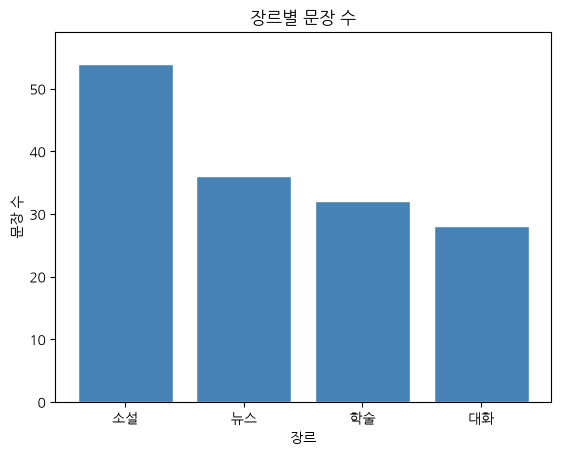

In [3]:
counts = texts['장르'].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_ylim(0, counts.max() + 5)
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
plt.show()

value_counts로 장르별 문장 수를 세어 막대그래프로
set_ylim으로 y축을 0부터 시작하게 해서 막대 높이의 비교가 왜곡되지 않게

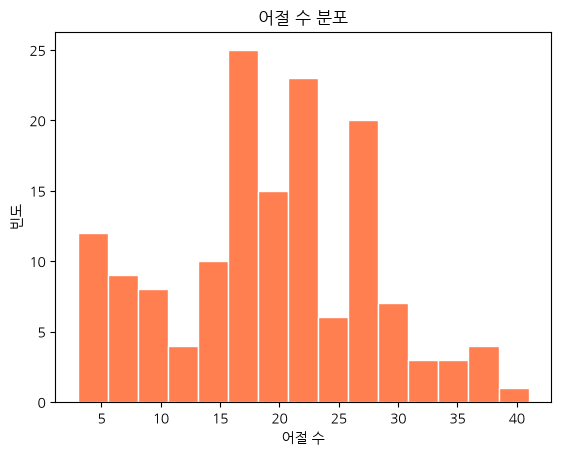

In [4]:
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white', color='coral')
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('빈도')
plt.show()

어절 수는 대체로 10~30 구간에 가장 많이 몰려 있음
대화소설뉴스 장르의 평균 어절 수가 그 부근에 분포하기 때문

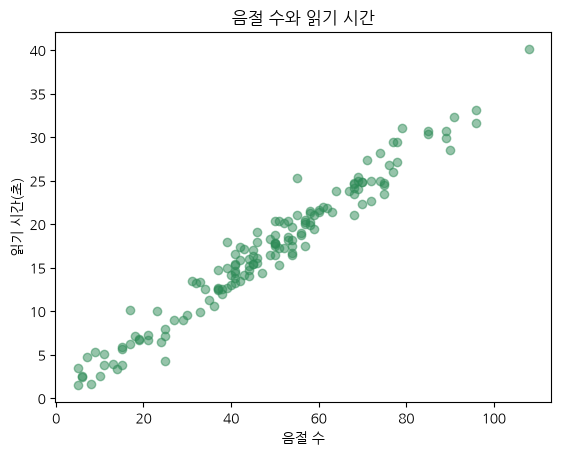

In [5]:
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.5, color='seagreen')
ax.set_title('음절 수와 읽기 시간')
ax.set_xlabel('음절 수')
ax.set_ylabel('읽기 시간(초)')
plt.show()

우상향 관계 --> 읽기시간이 음절수에 비례하도록 되었기 때문

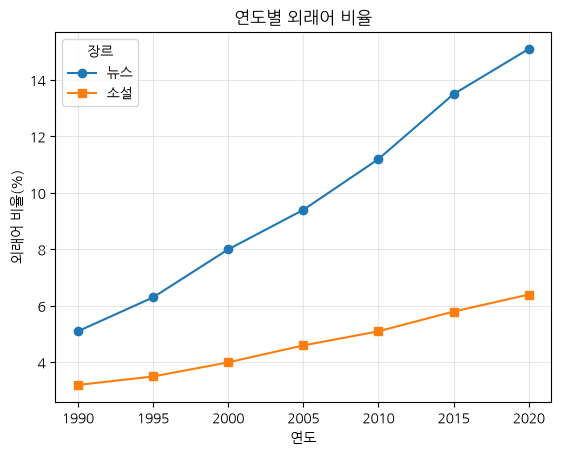

In [6]:
fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율(%)')
plt.show()

두 장르 모두 외래어 비율이 꾸준히 증가
뉴스의 증가 속도가 소설보다 훨씬 가팔라 시간이 지날수록 두 장르 간 격차가 벌어

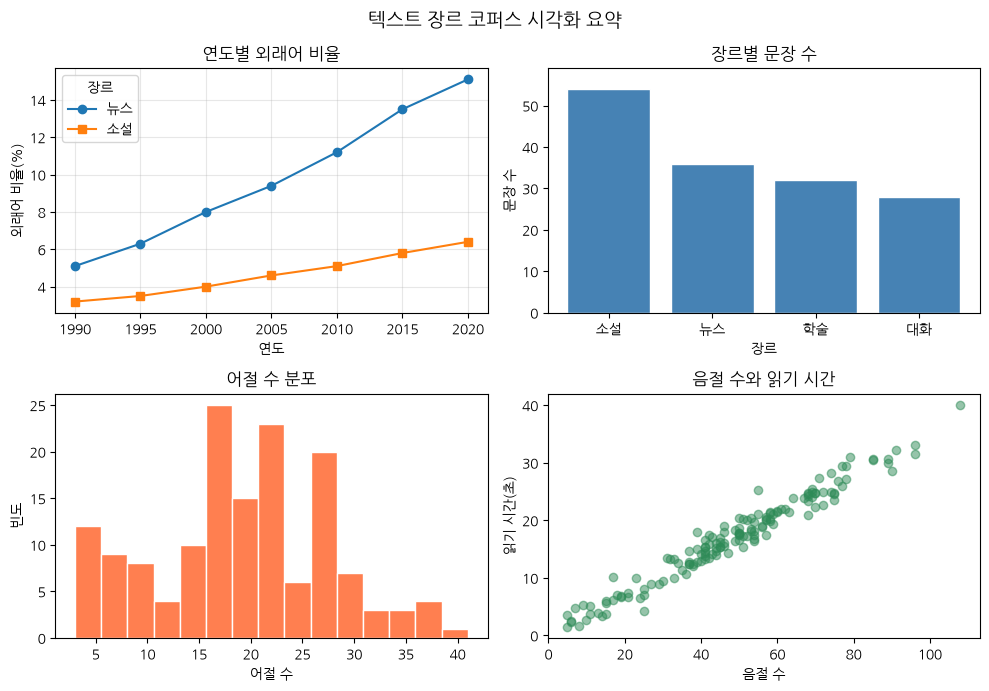

In [9]:
counts = texts['장르'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].legend(title='장르')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_title('연도별 외래어 비율')
axes[0, 0].set_xlabel('연도')
axes[0, 0].set_ylabel('외래어 비율(%)')

axes[0, 1].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0, 1].set_ylim(0, counts.max() + 5)
axes[0, 1].set_title('장르별 문장 수')
axes[0, 1].set_xlabel('장르')
axes[0, 1].set_ylabel('문장 수')

axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white', color='coral')
axes[1, 0].set_title('어절 수 분포')
axes[1, 0].set_xlabel('어절 수')
axes[1, 0].set_ylabel('빈도')

axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.5, color='seagreen')
axes[1, 1].set_title('음절 수와 읽기 시간')
axes[1, 1].set_xlabel('음절 수')
axes[1, 1].set_ylabel('읽기 시간(초)')

fig.suptitle('텍스트 장르 코퍼스 시각화 요약', fontsize=14)
fig.tight_layout()

#복붙
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()


2-2 격자 그린 네 그래프를 배치
suptitle로 전체 제목을, tight_layout으로 겹침을 방지

In [12]:
!pip install seaborn   # 12번 셀이 오류가 나 지피티를 찾아보닌 설치하라고 알려주었습니다.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


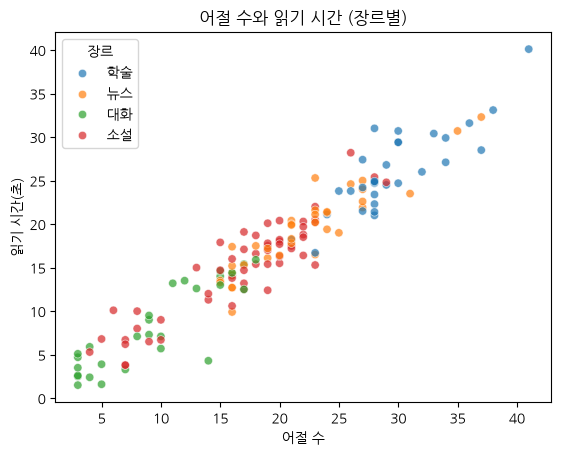

In [13]:
import seaborn as sns

fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', alpha=0.7, ax=ax)
ax.set_title('어절 수와 읽기 시간 (장르별)')
ax.set_xlabel('어절 수')
ax.set_ylabel('읽기 시간(초)')
plt.show()

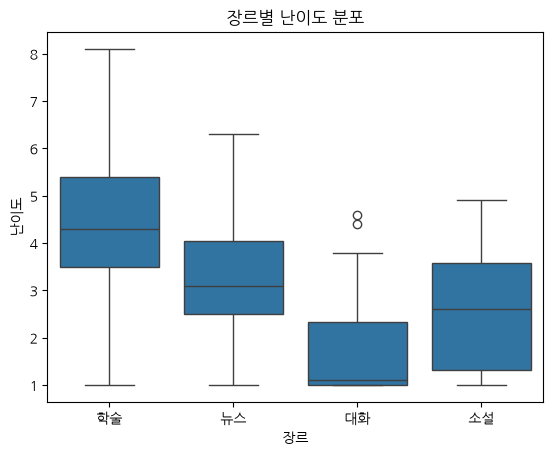

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.show()

난이도가 가장 높은 장르는 어절 수가 가장 많은 학술
상자의 크기도 어절 수 변동이 큰 학술 또는 뉴스 장르에서 가장 크게 나타남

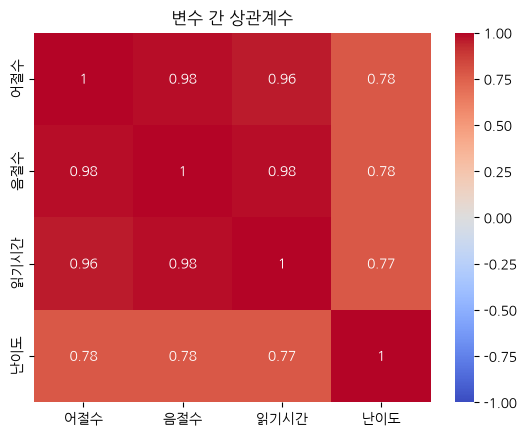

In [15]:
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

서로 가장 강하게 함께 증가하는 두 변수는 음절수와 읽기시간
데이터 생성 규칙상 읽기시간이 음절수에 직접 비례하도록 만들어졌기 때문에 음절이 많을수록 읽는 데 걸리는 시간이 거의 선형적으로 늘어나 상관계수가 1에 가깝게 나타남

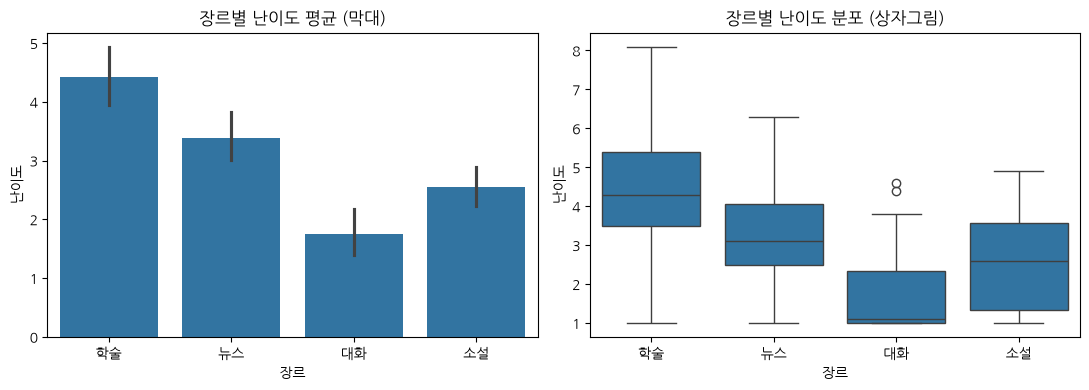

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도 평균 (막대)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('난이도')

sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포 (상자그림)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('난이도')

fig.tight_layout()
plt.show()


왼쪽 막대 그래프는 각 장르의 난이도를 평균이라는 하나의 값으로만 보여주기 때문에 분산, 중앙값, 이상치 같은 분포 정보를 모두 숨김
오른쪽 상자그림은 이러한 퍼짐과 중앙값, 이상치를 함께 드러내 더 솔직한? 정직한? 비교가 가능

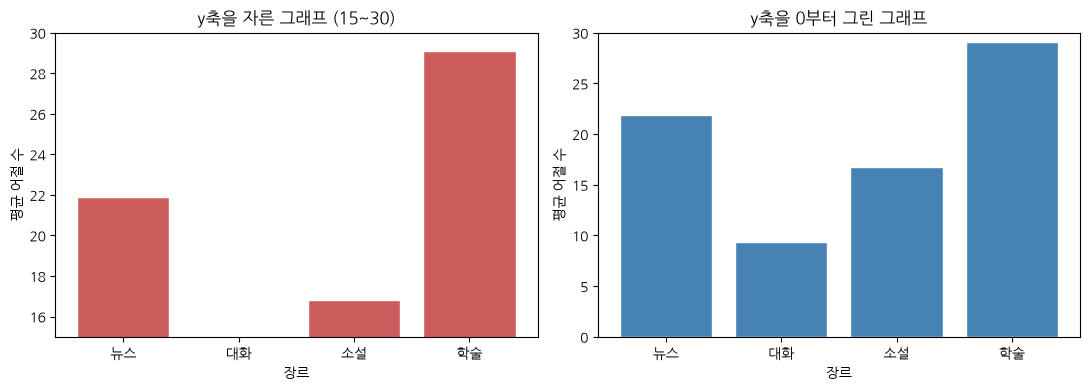

In [17]:
mean_words = texts.groupby('장르')['어절수'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽: y축을 잘라서 그림
axes[0].bar(mean_words.index, mean_words.values, color='indianred', edgecolor='white')
axes[0].set_ylim(15, 30)
axes[0].set_title('y축을 자른 그래프 (15~30)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('평균 어절 수')

# 오른쪽: 0부터 그림
axes[1].bar(mean_words.index, mean_words.values, color='steelblue', edgecolor='white')
axes[1].set_ylim(0, 30)
axes[1].set_title('y축을 0부터 그린 그래프')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('평균 어절 수')

fig.tight_layout()
plt.show()


두 그래프는 완전히 같은 숫자를 그렸지만, 왼쪽처럼 y축을 15부터 자르면 장르 간 막대 높이 차이가 실제보다 훨씬 크게 과장되어 보임
반면 오른쪽처럼 0부터 그리면 차이가 실제 비율대로 표현되어 장르 간 차이가 그리 크지 않음을 알 수 있음
막대 그래프는 막대의 길이로 양을 비교하는 그래프이므로 길이가 값에 정확히 비례하도록 반드시 y축을 0부터 시작해야 함